<a href="https://colab.research.google.com/github/Adib-Ishraq/Coding-a-LLM-from-scratch/blob/main/3_Implementing_a_GPT_model_from_Scratch_To_Generate_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

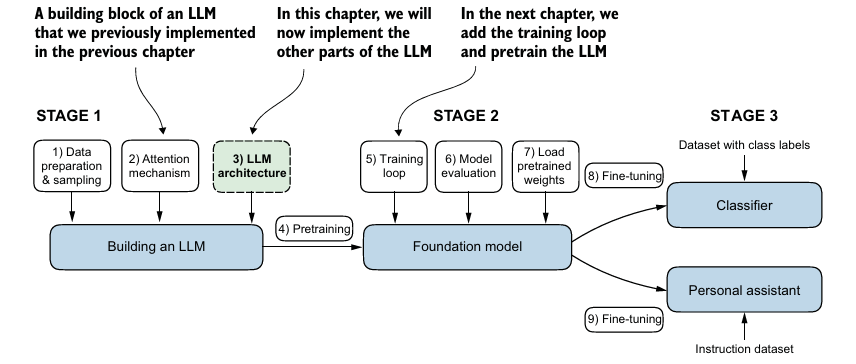

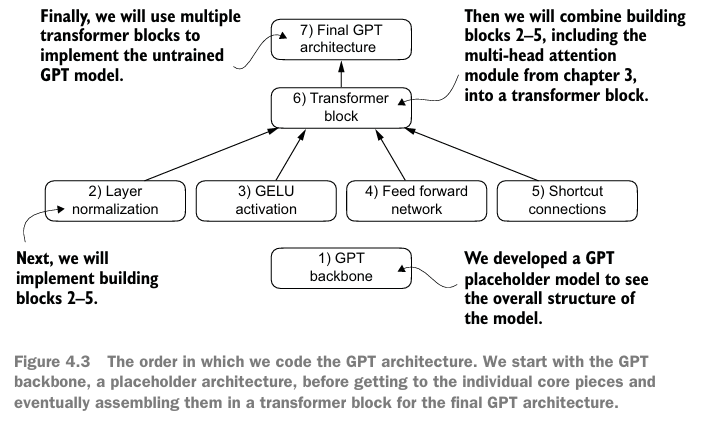

Birds Eye View

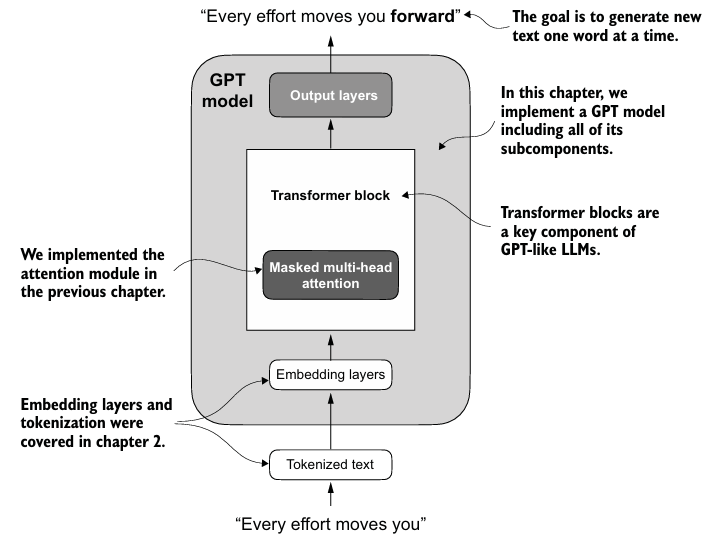

Inside of a Transformer

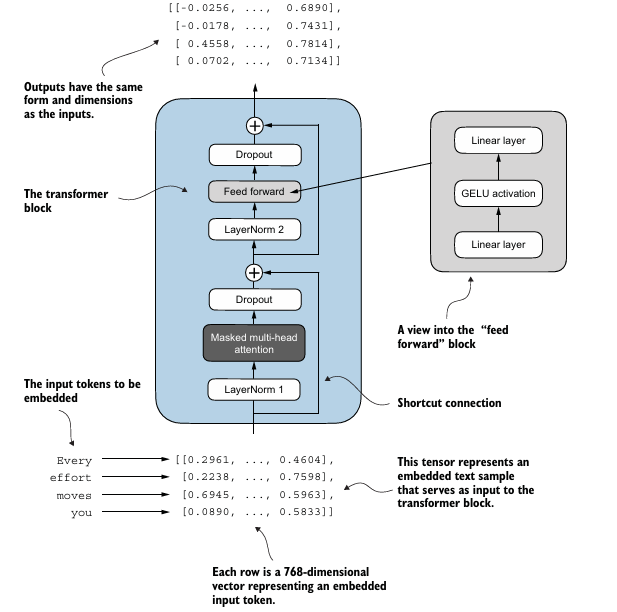



Full step

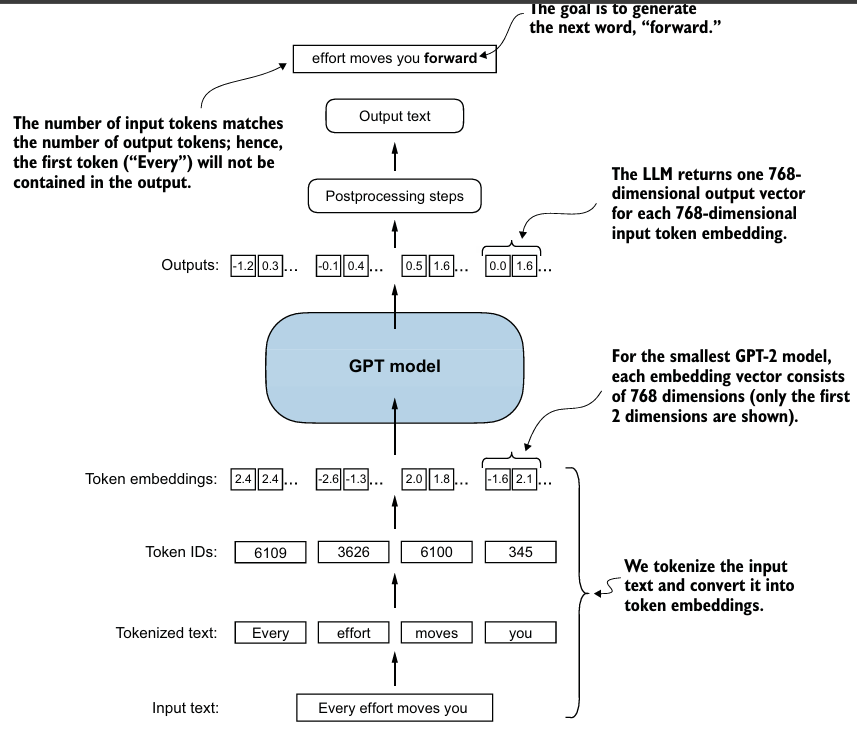

 we will focus on
loading pretrained weights into our implementation and adapting it for larger GPT-2
models with 345, 762, and 1,542 million parameters.


Note that we are focusing on GPT-2 because OpenAI has made the weights of the
pretrained model publicly available

We specify the configuration of the small GPT-2 model via the following Python dictionary, which we will use in the code examples later:



```
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}
```



In the GPT_CONFIG_124M dictionary, we use concise variable names for clarity and to
prevent long lines of code:
* vocab_size refers to a vocabulary of 50,257 words, as used by the BPE tokenizer.

* context_length denotes the maximum number of input tokens the model can
handle via the positional embeddings.

* emb_dim represents the embedding size, transforming each token into a 768
dimensional vector.

* n_heads indicates the count of attention heads in the multi-head attention
mechanism.
* n_layers specifies the number of transformer blocks in the model, which we
will cover in the upcoming discussion.
* drop_rate indicates the intensity of the dropout mechanism (0.1 implies a 10%
random drop out of hidden units) to prevent overfitting.
* qkv_bias determines whether to include a bias vector in the Linear layers of
the multi-head attention for query, key, and value computations. We will initially
disable this, following the norms of modern LLMs, but we will revisit it in chap
ter 6 when we load pretrained GPT-2 weights from OpenAI into our model.

Using this configuration, we will implement a GPT placeholder architecture (Dummy
GPTModel)

#  Part 1: DummyGPT model class

In [68]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [69]:
import torch
import torch.nn as nn
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
      super().__init__()
      self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
      self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
      self.drop_emb = nn.Dropout(cfg["drop_rate"])
      self.trf_blocks = nn.Sequential(
          *[DummyTransformerBlock(cfg)
            for _ in range(cfg["n_layers"])]
      )
      self.final_norm = DummyLayerNorm(cfg["emb_dim"])
      self.out_head = nn.Linear(
          cfg["emb_dim"], cfg["vocab_size"], bias=False
      )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
      super().__init__()
    def forward(self, x):
      return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
      super().__init__()
    def forward(self, x):
      return x


**Step 1: Tokenization**

In [70]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


**Step 2: Create an instance of DUMMYGPT model**

In [71]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output logit shape:", logits.shape) # batch, token id, vocab size
print(logits)

Output logit shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


The output tensor has two rows corresponding to the two text samples. Each text sam
ple consists of four tokens; each token is a 50,257-dimensional vector, which matches
the size of the tokenizer’s vocabulary.
The embedding has 50,257 dimensions because each of these dimensions refers to
a unique token in the vocabulary. When we implement the postprocessing code, we
will convert these 50,257-dimensional vectors back into token IDs, which we can then
decode into words.
Now that we have taken a top-down look at the GPT architecture and its inputs and
outputs, we will code the individual placeholders, starting with the real layer normal
ization class that will replace the DummyLayerNorm in the previous code

# Normalizing activations with layer normalization

* Training deep neural networks with many layers can sometimes prove challenging
due to problems like vanishing or exploding gradients.

* These problems lead to unsta
ble training dynamics and make it difficult for the network to effectively adjust its
weights, which means the learning process struggles to find a set of parameters
(weights) for the neural network that minimizes the loss function.

* so we  implement layer normalization to improve the stability and efficiency of neu
ral network training.

* The main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also known as unit variance.

* tackles internal covariate shift. layer norm will make sure mean and std dev of the output is fixed



Main idea: Adjust outputs of neural network such that mean zero and variance of one which speeds convergence.

**In GPT-2 and modern transformer
architectures, layer normalization is typically applied before and after the multi-head attention module, and, as we have seen with the DummyLayerNorm placeholder, before the final output layer**

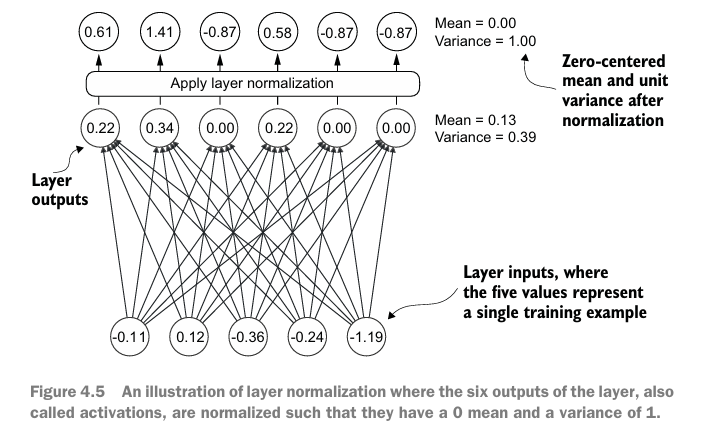

Simple example

In [72]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [73]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


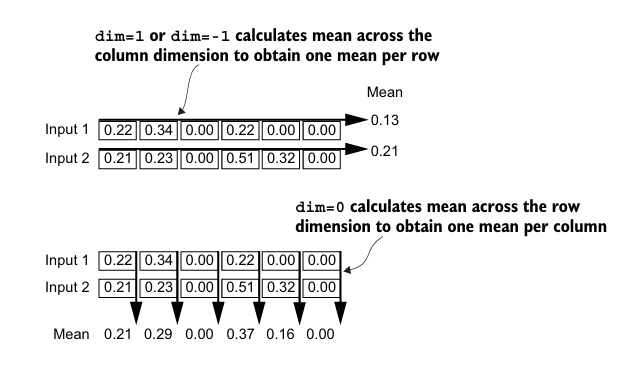

The first row in the mean tensor here contains the mean value for the first input row,
and the second output row contains the mean for the second input row.
Using keepdim=True in operations like mean or variance calculation ensures that the
output tensor retains the same number of dimensions as the input tensor, even though
the operation reduces the tensor along the dimension specified via dim. For instance,
without keepdim=True, the returned mean tensor would be a two-dimensional vector
[0.1324, 0.2170] instead of a 2 × 1–dimensional matrix [[0.1324], [0.2170]].
The dim parameter specifies the dimension along which the calculation of the statis
tic (here, mean or variance) should be performed in a tensor.

In [74]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Note that the value –5.9605e-08 in the output tensor is the scientific notation for–5.9605 × 10-8, which is –0.000000059605 in decimal form. This value is very close to 0,
but it is not exactly 0 due to small numerical errors that can accumulate because of
the finite precision with which computers represent numbers.
To improve readability, we can also turn off the scientific notation when printing
tensor values by setting sci_mode to False:

In [75]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Let's implement LayerNorm Class

* This specific implementation of layer normalization operates on the last dimension of
the input tensor x, which represents the embedding dimension (emb_dim).

* The variable eps is a small constant (epsilon) added to the variance to prevent division by zero
during normalization.


* The scale and shift are two trainable parameters (of the
same dimension as the input) that the LLM automatically adjusts during training if it
is determined that doing so would improve the model’s performance on its training
task. This allows the model to learn appropriate scaling and shifting that best suit the
data it is processing.

In [76]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift #

In [77]:
print(batch_example)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])


In [78]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


**Layer normalization vs. batch normalization**:
If you are familiar with batch normalization, a common and traditional normalization
method for neural networks, you may wonder how it compares to layer normalization.
Unlike batch normalization, which normalizes across the batch dimension, layer normalization normalizes across the feature dimension. LLMs often require significant computational resources, and the available hardware or the specific use case can
dictate the batch size during training or inference. Since layer normalization normal
izes each input independently of the batch size, it offers more flexibility and stability
in these scenarios. This is particularly beneficial for distributed training or when
deploying models in environments where resources are constrained.

# Implementing a feed forward network with GELU activations

Historically, the ReLU activation function has been commonly used in deep learning
due to its simplicity and effectiveness across various neural network architectures.
However, in LLMs, several other activation functions are employed beyond the tradi
tional ReLU. Two notable examples are GELU (Gaussian error linear unit) and SwiGLU
(Swish-gated linear unit).
GELU and SwiGLU are more complex and smooth activation functions incorporating Gaussian and sigmoid-gated linear units, respectively. They offer improved per
formance for deep learning models, unlike the simpler ReLU.

The GELU activation function can be implemented in several ways; the exact ver
sion is defined as GELU(x) = x⋅Φ(x), where Φ(x) is the cumulative distribution function of the standard Gaussian distribution.
In practice, however, it’s common to
implement a computationally cheaper approximation (the original GPT-2 model was
also trained with this approximation, which was found via curve fitting):
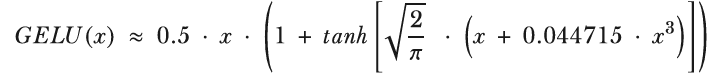

In [79]:
class GELU(nn.Module):
    def __init__(self):
      super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


It is differantiable so it is smooth

Deals with dead neuron problem

Seems to work better with LLMs

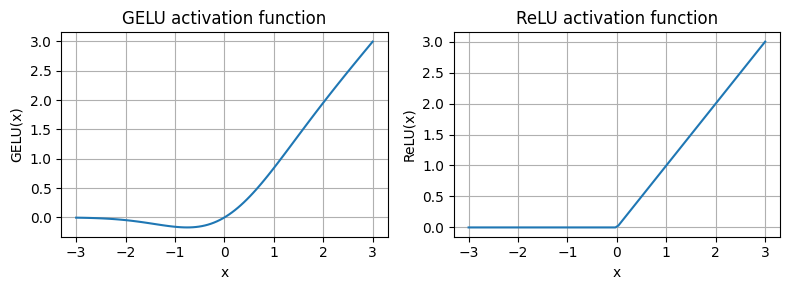

In [80]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

# A feed forward neural network module

In [81]:
print(GPT_CONFIG_124M)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}


In [82]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),#expansion
            GELU(),# activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),#contraction
        )
    def forward(self, x):
        return self.layers(x)

As we can see, the FeedForward module is a small neural network consisting of two
Linear layers and a GELU activation function. In the 124-million-parameter GPT
model, it receives the input batches with tokens that have an embedding size of 768
each via the GPT_CONFIG_124M dictionary where GPT_CONFIG_ 124M["emb_dim"] = 768.

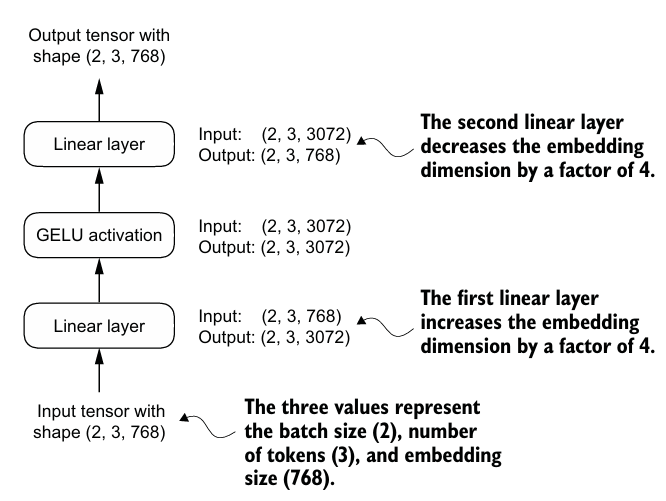

 An overview of the connections between the layers of the
feed forward neural network. This neural network can accommodate
variable batch sizes and numbers of tokens in the input. However, the
embedding size for each token is determined and fixed when initializing
the weights

In [83]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


Moreover, the uniformity in input and output dimensions simplifies the architecture
by enabling the stacking of multiple layers, as we will do later, without the need to
adjust dimensions between them, thus making the model more scalable.

# Shorcut Connections

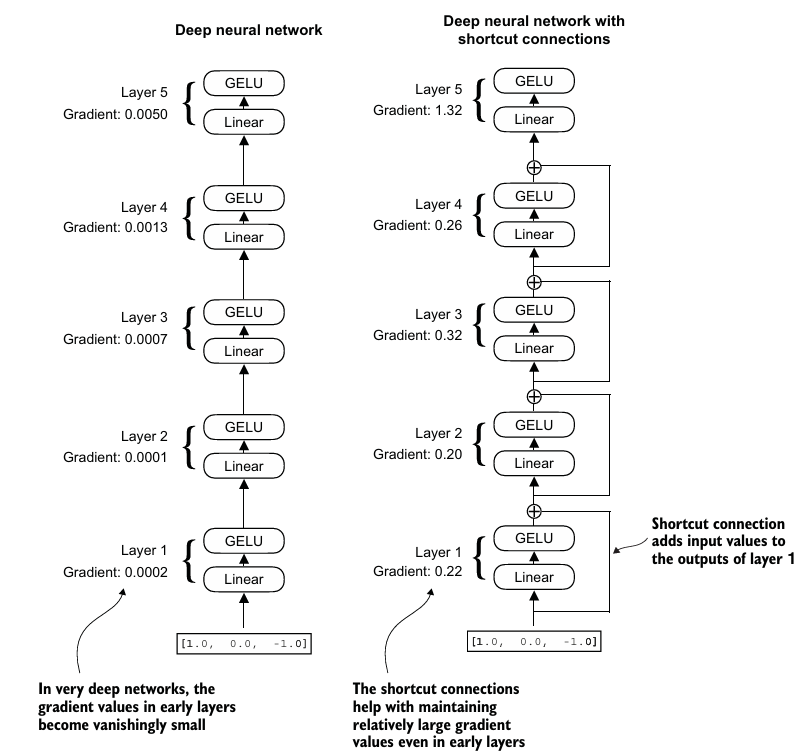

 Originally, shortcut connections were proposed for deep networks in
computer vision (specifically, in residual networks) to mitigate the challenge of vanishing gradients. The vanishing gradient problem refers to the issue where gradients
(which guide weight updates during training) become progressively smaller as they
propagate backward through the layers, making it difficult to effectively train earlier
layers.

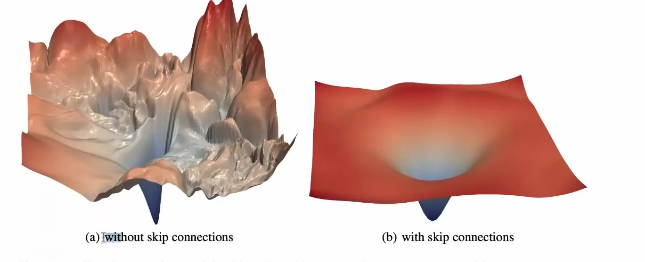

In [84]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
          nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                        GELU()),
          nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                        GELU()),
          nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                        GELU()),
          nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                        GELU()),
          nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                        GELU())
          ])

    def forward(self, x):
      for layer in self.layers:
          layer_output = layer(x)
          if self.use_shortcut and x.shape == layer_output.shape:
              x = x + layer_output
          else:
              x = layer_output
      return x

In [85]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

In [86]:
def print_gradients(model, x):
  output = model(x)
  target = torch.tensor([[0.]])
  loss = nn.MSELoss()
  loss = loss(output, target)
  loss.backward()
  for name, param in model.named_parameters():
    if 'weight' in name:
      print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [87]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [88]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


The last layer (layers.4) still has a larger gradient than the other layers. However,
the gradient value stabilizes as we progress toward the first layer (layers.0) and
doesn’t shrink to a vanishingly small value.

In conclusion, shortcut connections are important for overcoming the limitations
posed by the vanishing gradient problem in deep neural networks. Shortcut connections are a core building block of very large models such as LLMs, and they will help facilitate more effective training by ensuring consistent gradient flow across layers when we train the GPT model.

#  Transformer block
Multihead attention

Layer Norm

DropOut

feed forward layers

GELU activation

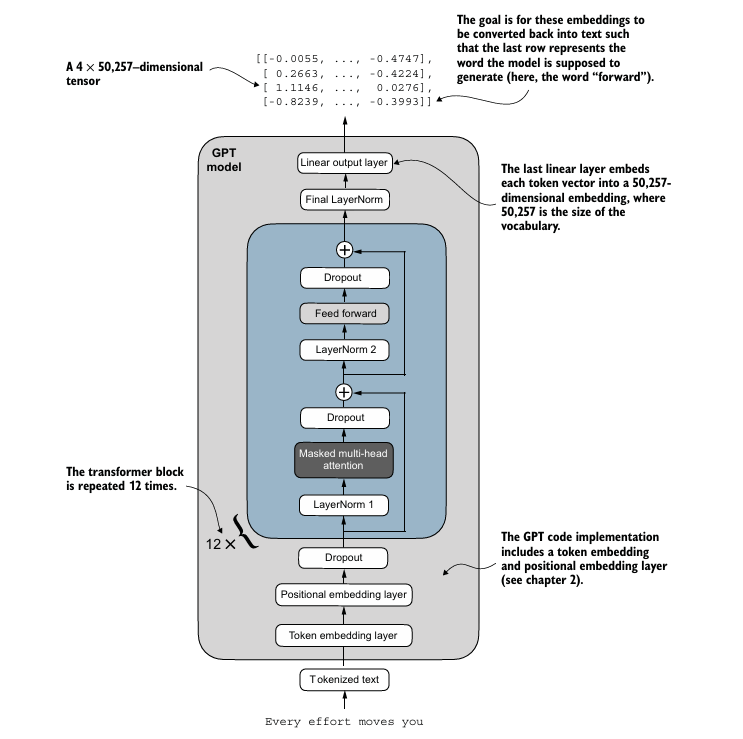

In [89]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

Building blocks: Layer Norm+ DropOut+ feed forward layers+ GELU activation

In [90]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
      super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), # expansion
            GELU(),# activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), # contraction
        )
    def forward(self, x):
        return self.layers(x)

Let us code a transformer block as follows:

Step 1: Shortcut connection for attention block

Step 2: Shortcut connection for feed forward block

Step 3: Add the original input back

In [91]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
         context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                      diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(
            b, num_tokens, self.num_heads, self.head_dim
        )
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)
        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec

In [92]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x) # shape [batch size,num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut     # add the original input back

        # shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x



In [93]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


As we can see, the transformer block maintains the input dimensions in its output, indi
cating that the transformer architecture processes sequences of data without altering
their shape throughout the network.
The preservation of shape throughout the transformer block architecture is not
incidental but a crucial aspect of its design. This design enables its effective application across a wide range of sequence-to-sequence tasks, where each output vector
directly corresponds to an input vector, maintaining a one-to-one relationship.


How
ever, the output is a context vector that encapsulates information from the entire
input sequence. This means that while the physical dimensions of the
sequence (length and feature size) remain unchanged as it passes through the transformer block, the content of each output vector is re-encoded to integrate contextual
information from across the entire input sequence.

# Coding the GPT model

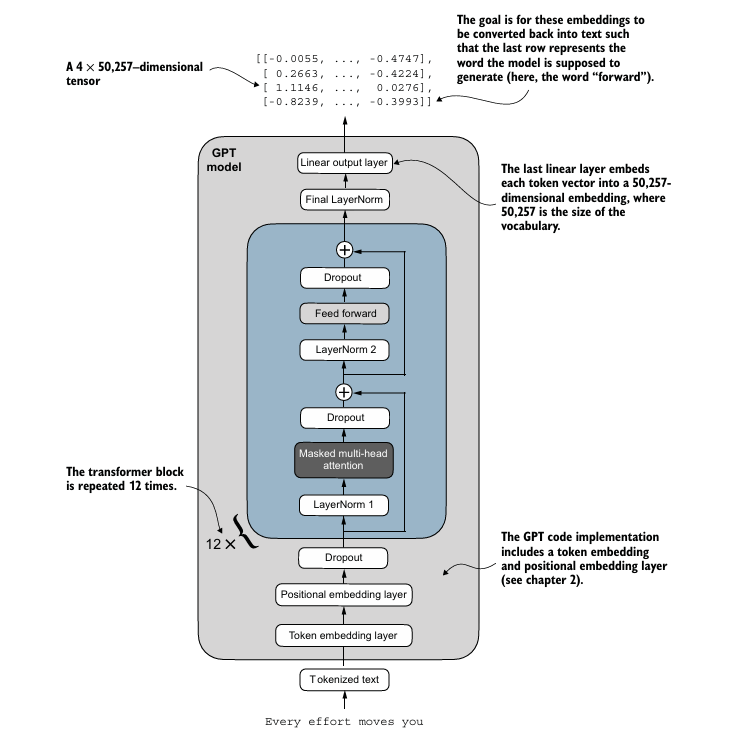

In [94]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [95]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
      super().__init__()
      self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
      self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
      self.drop_emb = nn.Dropout(cfg["drop_rate"])
      self.trf_blocks = nn.Sequential(
          *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
      self.final_norm = LayerNorm(cfg["emb_dim"])
      self.out_head = nn.Linear(
          cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [96]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [97]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


Earlier, we spoke of initializing
a 124-million-parameter GPT model, so why is the actual number of parameters
163 million?


The reason is a concept called weight tying, which was used in the original GPT-2
architecture. It means that the original GPT-2 architecture reuses the weights from
the token embedding layer in its output layer. To understand better, let’s take a look at
the shapes of the token embedding layer and linear output layer that we initialized on
the model via the GPTModel earlier:

In [98]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


As we can see from the print outputs, the weight tensors for both these layers have the
same shape:

The token embedding and output layers are very large due to the number of rows for
the 50,257 in the tokenizer’s vocabulary. Let’s remove the output layer parameter
count from the total GPT-2 model count according to the weight tying:

In [99]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying\n: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying
: 124,412,160


In [100]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


In conclusion, by calculating the memory requirements for the 163 million parame
ters in our GPTModel object and assuming each parameter is a 32-bit float taking up 4
bytes, we find that the total size of the model amounts to 621.83 MB, illustrating the
relatively large storage capacity required to accommodate even relatively small LLMs.

# Generating text

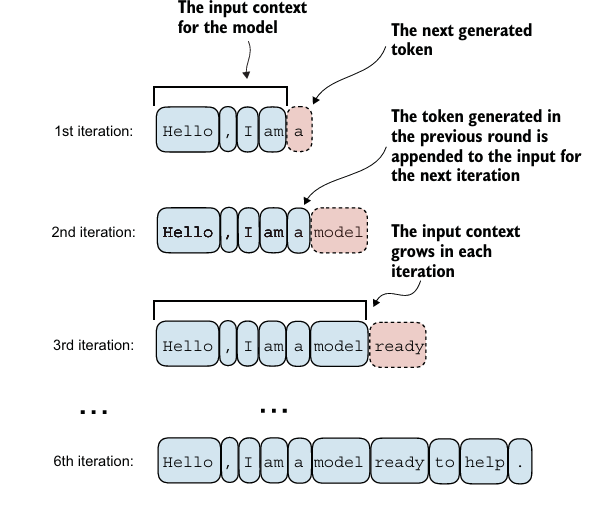

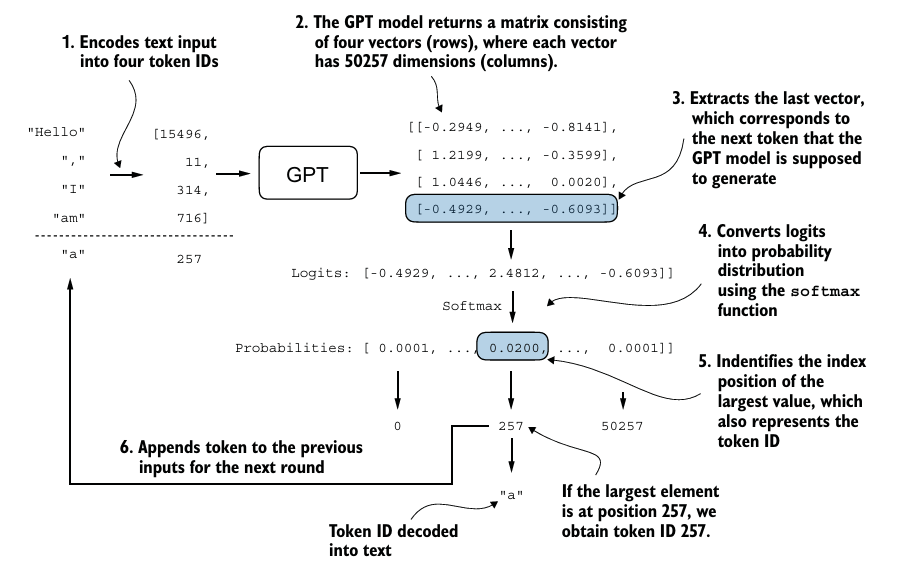

In [101]:
def generate_text_simple(model, idx,
                 max_new_tokens, context_size):
    for _ in range(max_new_tokens):
      idx_cond = idx[:, -context_size:]
      with torch.no_grad():
          logits = model(idx_cond)
      logits = logits[:, -1, :]
      probas = torch.softmax(logits, dim=-1)
      idx_next = torch.argmax(probas, dim=-1, keepdim=True)
      idx = torch.cat((idx, idx_next), dim=1)
    return idx


In [102]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


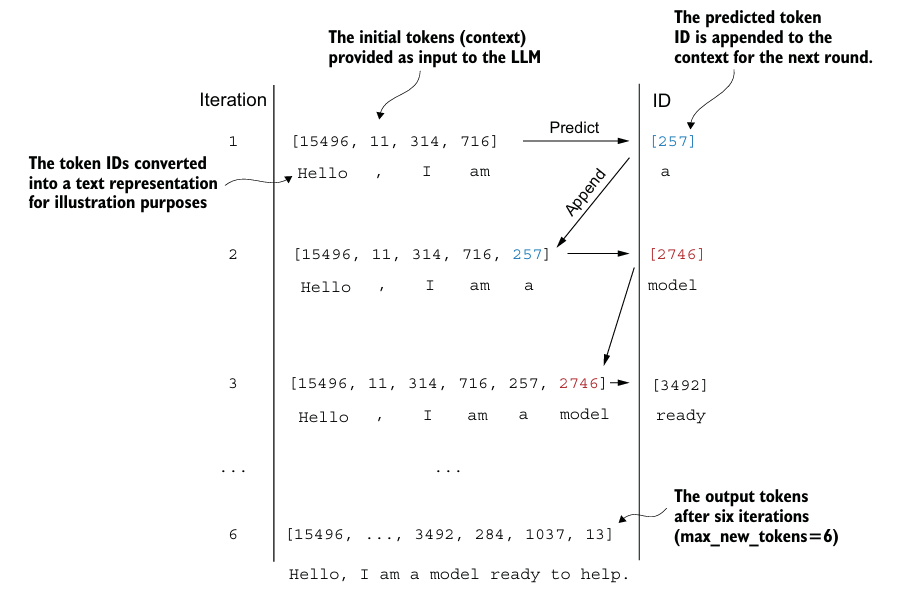

In [103]:
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,

    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [104]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


As we can see, the model generated gibberish, which is not at all like the coherent text
Hello, I am a model ready to help. What happened? The reason the model is unable to
produce coherent text is that we haven’t trained it yet. So far, we have only implemented
the GPT architecture and initialized a GPT model instance with initial random weights.
